In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
adhamashraf202200953_synthetic_code_dataset_for_plagiarism_detection_path = kagglehub.dataset_download('adhamashraf202200953/synthetic-code-dataset-for-plagiarism-detection')

print('Data source import complete.')

In [ ]:
! pip install pandas pyarrow

In [ ]:
!pip install -q gdown

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub

/kaggle/input/datasets/adhamashraf202200953/synthetic-code-dataset-for-plagiarism-detection/synthetic_spider_sql.parquet
/kaggle/input/datasets/adhamashraf202200953/synthetic-code-dataset-for-plagiarism-detection/synthetic_bcb_files.parquet
/kaggle/input/datasets/adhamashraf202200953/synthetic-code-dataset-for-plagiarism-detection/synthetic_codenet_python.parquet
/kaggle/input/datasets/adhamashraf202200953/synthetic-code-dataset-for-plagiarism-detection/synthetic_poj104.csv
/kaggle/input/datasets/adhamashraf202200953/synthetic-code-dataset-for-plagiarism-detection/synthetic_sql_plagiarism_pairs.csv
/kaggle/input/datasets/adhamashraf202200953/synthetic-code-dataset-for-plagiarism-detection/synthetic_mbpp_python.parquet
/kaggle/input/datasets/adhamashraf202200953/synthetic-code-dataset-for-plagiarism-detection/synthetic_codecontests_python.parquet


In [ ]:
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()
folder_url = user_secrets.get_secret("GDRIVE_FOLDER_URL")

In [ ]:
import gdown
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()
folder_url = user_secrets.get_secret("GDRIVE_FOLDER_URL")

gdown.download_folder(
    url=folder_url,
    output="dataset",
    quiet=False
)

Retrieving folder contents


Processing file 1OjNSBQUmJ03wqN29nGb9gPz8V1cLy8ff bigclonebench_test.parquet
Processing file 1R3214ua2j2oWd6fWQX6mPRgwm5RaJO5P bigclonebench_train.parquet
Processing file 1HPymwY33I0t74IcFBnWrnCDjdXf_GrJr bigclonebench_validation.parquet
Processing file 1AKPIzhMaLb4oMigWas4tyXJxSwVAC6FI poj104_test.csv
Processing file 1SorVnetyJPCHGIIosuMMTpXvoqTwikU6 poj104_train.csv
Processing file 12jyS7kXposPrLX6rwADu8Trqq71Bpus8 poj104_validation.csv
Processing file 19utnwjZu-Iam76O7b5zxYkfWl3YYok3N synthetic_poj104.csv


Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1OjNSBQUmJ03wqN29nGb9gPz8V1cLy8ff
From (redirected): https://drive.google.com/uc?id=1OjNSBQUmJ03wqN29nGb9gPz8V1cLy8ff&confirm=t&uuid=d5d34026-31af-44c6-8d5b-9008b6be1227
To: /kaggle/working/dataset/bigclonebench_test.parquet
100%|██████████| 395M/395M [00:04<00:00, 97.0MB/s] 
Downloading...
From (original): https://drive.google.com/uc?id=1R3214ua2j2oWd6fWQX6mPRgwm5RaJO5P
From (redirected): https://drive.google.com/uc?id=1R3214ua2j2oWd6fWQX6mPRgwm5RaJO5P&confirm=t&uuid=087e1afb-d904-4669-a5da-3c51ea98320a
To: /kaggle/working/dataset/bigclonebench_train.parquet
100%|██████████| 938M/938M [00:07<00:00, 124MB/s]  
Downloading...
From (original): https://drive.google.com/uc?id=1HPymwY33I0t74IcFBnWrnCDjdXf_GrJr
From (redirected): https://drive.google.com/uc?id=1HPymwY33I0t74IcFBnWrnCDjdXf_GrJr&confirm=t&uuid=b4ef09bc-ff90-4e1e

['dataset/bigclonebench_test.parquet',
 'dataset/bigclonebench_train.parquet',
 'dataset/bigclonebench_validation.parquet',
 'dataset/poj104_test.csv',
 'dataset/poj104_train.csv',
 'dataset/poj104_validation.csv',
 'dataset/synthetic_poj104.csv']

In [ ]:
import os

for root, dirs, files in os.walk("."):
    for f in files:
        print(os.path.join(root, f))

./.virtual_documents/__notebook_source__.ipynb
./dataset/poj104_train.csv
./dataset/bigclonebench_train.parquet
./dataset/poj104_validation.csv
./dataset/synthetic_poj104.csv
./dataset/poj104_test.csv
./dataset/bigclonebench_validation.parquet
./dataset/bigclonebench_test.parquet


## Loading Training / Original Data

In [ ]:
import os
import pandas as pd

DATA_DIR = "/kaggle/working/dataset"

train_dfs = {}

for file in os.listdir(DATA_DIR):
    filepath = os.path.join(DATA_DIR, file)

    if file.endswith("_train.csv"):
        df_name = file.replace(".csv", "")
        train_dfs[df_name] = pd.read_csv(filepath)

    elif file.endswith("_train.parquet"):
        df_name = file.replace(".parquet", "")
        train_dfs[df_name] = pd.read_parquet(filepath)

print("Loaded datasets:")
for name, df in train_dfs.items():
    print(f"{name}: {df.shape}")

Loaded datasets:
poj104_train: (32500, 3)
bigclonebench_train: (901028, 6)


In [ ]:
from datasets import load_dataset, concatenate_datasets

ds_sql = load_dataset(
    "b-mc2/sql-create-context",
    split="train"
)

train_dfs["sql_create_context"] = ds_sql.to_pandas()

ds_csn = load_dataset(
    "claudios/code_search_net",
    "python",
    split="train"
)

train_dfs["code_search_net_python"] = ds_csn.to_pandas()

all_python_functions = ds_csn["func_code_string"]

ds_mbpp = load_dataset(
    "google-research-datasets/mbpp",
    "sanitized",
    split="all"
)

train_dfs["mbpp"] = ds_mbpp.to_pandas()

spider_tr = load_dataset(
    "xlangai/spider",
    split="train"
)

spider_va = load_dataset(
    "xlangai/spider",
    split="validation"
)

ds_spider = concatenate_datasets([spider_tr, spider_va])

train_dfs["spider"] = ds_spider.to_pandas()

ds_cc = load_dataset(
    "deepmind/code_contests",
    split="train"
)

train_dfs["code_contests"] = ds_cc.to_pandas()

print(f"Loaded {len(train_dfs)} datasets\n")

for name, df in train_dfs.items():
    print(f"{name:25s} {df.shape}")

README.md: 0.00B [00:00, ?B/s]

sql_create_context_v4.json:   0%|          | 0.00/21.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/78577 [00:00<?, ? examples/s]

README.md: 0.00B [00:00, ?B/s]

python/train-00000-of-00003.parquet:   0%|          | 0.00/130M [00:00<?, ?B/s]

...

Generating train split:   0%|          | 0/13328 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/165 [00:00<?, ? examples/s]

Generating valid split:   0%|          | 0/117 [00:00<?, ? examples/s]

Loading dataset shards:   0%|          | 0/24 [00:00<?, ?it/s]

Loaded 7 datasets

poj104_train              (32500, 3)
bigclonebench_train       (901028, 6)
sql_create_context        (78577, 3)
code_search_net_python    (412178, 8)
mbpp                      (427, 6)
spider                    (8034, 6)
code_contests             (13328, 20)


In [ ]:
def print_first_row(df):
    if df.empty:
        return

    first_row_dict = df.iloc[0].to_dict()

    for key, value in first_row_dict.items():
        print(f"Key: '{key}'")
        print("-" * 40)
        print(value)
        print("=" * 40 + "\n")

## Loading Synthetic Data

In [ ]:
# ---------------------------------------------------------
# Read Parquet Files
# ---------------------------------------------------------
df_bcb_synthetic = pd.read_parquet('/kaggle/input/datasets/adhamashraf202200953/synthetic-code-dataset-for-plagiarism-detection/synthetic_bcb_files.parquet')
df_codecontests_synthetic = pd.read_parquet('/kaggle/input/datasets/adhamashraf202200953/synthetic-code-dataset-for-plagiarism-detection/synthetic_codecontests_python.parquet')
df_codenet_synthetic = pd.read_parquet('/kaggle/input/datasets/adhamashraf202200953/synthetic-code-dataset-for-plagiarism-detection/synthetic_codenet_python.parquet')
df_mbpp_synthetic = pd.read_parquet('/kaggle/input/datasets/adhamashraf202200953/synthetic-code-dataset-for-plagiarism-detection/synthetic_mbpp_python.parquet')
df_spider_synthetic = pd.read_parquet('/kaggle/input/datasets/adhamashraf202200953/synthetic-code-dataset-for-plagiarism-detection/synthetic_spider_sql.parquet')

# ---------------------------------------------------------
# Read CSV Files
# ---------------------------------------------------------
df_poj104_synthetic = pd.read_csv('/kaggle/input/datasets/adhamashraf202200953/synthetic-code-dataset-for-plagiarism-detection/synthetic_poj104.csv')
df_sql_plagiarism_synthetic = pd.read_csv('/kaggle/input/datasets/adhamashraf202200953/synthetic-code-dataset-for-plagiarism-detection/synthetic_sql_plagiarism_pairs.csv')

print ("All the data loaded successfully")

All the data loaded successfully


In [ ]:
synthetics_dataframes = {
    "Synthetic BCB": df_bcb_synthetic,
    "Synthetic CodeContests": df_codecontests_synthetic,
    "Synthetic CodeNet": df_codenet_synthetic,
    "Synthetic MBPP": df_mbpp_synthetic,
    "Synthetic Spider SQL": df_spider_synthetic,
    "Synthetic POJ104": df_poj104_synthetic,
    "Synthetic SQL Plagiarism": df_sql_plagiarism_synthetic
}

for name, df in synthetics_dataframes.items():
    print(f"{'#' * 60}")
    print(f"Data Set Name: {name}")
    print_first_row(df)
    print("\n")

############################################################
Data Set Name: Synthetic BCB
Key: 'func'
----------------------------------------
private long retrieveLastModified(String remoteUrl) {
    try {
        URL resource = new URL(remoteUrl);
        HttpURLConnection connection = (HttpURLConnection) resource.openConnection();
        return connection.getLastModified();
    } catch (IOException error) {
        LOG.warn("Failed to open URL: " + error.getMessage(), error);
        return 0;
    }
}

Key: 'functional_group'
----------------------------------------
0



############################################################
Data Set Name: Synthetic CodeContests
Key: 'id'
----------------------------------------
2

Key: 'original_code'
----------------------------------------
Competitive Programming Solution

Key: 'ai_variant_code'
----------------------------------------
def calculate_gcd(x, y):
    while y != 0:
        x, y = y, x % y
    return x

num_lines = int(input())

In [ ]:
original_dataframes = {
    "Original BCB": train_dfs["bigclonebench_train"],
    "Original CodeContests": train_dfs["code_contests"],
    "Original CodeNet": train_dfs["code_search_net_python"],
    "Original MBPP": train_dfs["mbpp"],
    "Original Spider SQL": train_dfs["spider"],
    "Original POJ104": train_dfs["poj104_train"],
    "Original SQL Plagiarism": train_dfs["sql_create_context"]
}

In [ ]:
for name, df in original_dataframes.items():
    print(f"{'#' * 60}")
    print(f"Data Set Name: {name}")
    print_first_row(df)
    print("\n")

############################################################
Data Set Name: Original BCB
Key: 'id'
----------------------------------------
0

Key: 'id1'
----------------------------------------
13988825

Key: 'id2'
----------------------------------------
8660836

Key: 'func1'
----------------------------------------
    private void setNodekeyInJsonResponse(String service) throws Exception {
        String filename = this.baseDirectory + service + ".json";
        Scanner s = new Scanner(new File(filename));
        PrintWriter fw = new PrintWriter(new File(filename + ".new"));
        while (s.hasNextLine()) {
            fw.println(s.nextLine().replaceAll("NODEKEY", this.key));
        }
        s.close();
        fw.close();
        (new File(filename + ".new")).renameTo(new File(filename));
    }


Key: 'func2'
----------------------------------------
    public void transform(String style, String spec, OutputStream out) throws IOException {
        URL url = new URL(rootURL, spe

## Migrating original and synthetic data

In [ ]:
standardized_dfs = []

In [ ]:
df_mbpp_std = pd.DataFrame({
    'code_a': synthetics_dataframes["Synthetic MBPP"]['original_code'],
    'code_b': synthetics_dataframes["Synthetic MBPP"]['ai_variant_code'],
    'label': 1, 'language': 'python', 'dataset': 'MBPP'
})
standardized_dfs.append(df_mbpp_std)

In [ ]:
df_cc_std = pd.DataFrame({
    'code_a': synthetics_dataframes["Synthetic CodeContests"]['original_code'],
    'code_b': synthetics_dataframes["Synthetic CodeContests"]['ai_variant_code'],
    'label': 1, 'language': 'python', 'dataset': 'CodeContests'
})
standardized_dfs.append(df_cc_std)

In [ ]:
df_spider_std = pd.DataFrame({
    'code_a': synthetics_dataframes["Synthetic Spider SQL"]['original_code'],
    'code_b': synthetics_dataframes["Synthetic Spider SQL"]['ai_variant_code'],
    'label': 1, 'language': 'sql', 'dataset': 'Spider'
})
standardized_dfs.append(df_spider_std)

In [ ]:
df_sqlplag_std = pd.DataFrame({
    'code_a': synthetics_dataframes["Synthetic SQL Plagiarism"]['original_sql'],
    'code_b': synthetics_dataframes["Synthetic SQL Plagiarism"]['plagiarized_sql'],
    'label': 1, 'language': 'sql', 'dataset': 'SQL_Plagiarism'
})
standardized_dfs.append(df_sqlplag_std)

In [ ]:
synth_codenet = synthetics_dataframes["Synthetic CodeNet"]
orig_codenet = original_dataframes["Original CodeNet"]
orig_codenet_matched = orig_codenet.loc[synth_codenet['id']]

df_codenet_std = pd.DataFrame({
    'code_a': orig_codenet_matched['func_code_string'].values,
    'code_b': synth_codenet['code'].values,
    'label': 1, 'language': 'python', 'dataset': 'CodeNet'
})
standardized_dfs.append(df_codenet_std)

In [ ]:
df_poj104_std = pd.DataFrame({
    'code_a': original_dataframes["Original POJ104"]['code'].values,
    'code_b': synthetics_dataframes["Synthetic POJ104"]['code'].values,
    'label': 1, 'language': 'cpp', 'dataset': 'POJ104'
})
standardized_dfs.append(df_poj104_std)

In [ ]:
synth_bcb = synthetics_dataframes["Synthetic BCB"]
orig_bcb = original_dataframes["Original BCB"]
orig_bcb_matched = orig_bcb.head(len(synth_bcb))

df_bcb_std = pd.DataFrame({
    'code_a': orig_bcb_matched['func1'].values,
    'code_b': synth_bcb['func'].values,
    'label': 1, 'language': 'java', 'dataset': 'BCB'
})
standardized_dfs.append(df_bcb_std)

In [ ]:
final_positive_data = pd.concat(standardized_dfs, ignore_index=True)

print(f"Total Clean Positive Pairs: {len(final_positive_data)}")
print(final_positive_data.isnull().sum())

Total Clean Positive Pairs: 110961
code_a      0
code_b      0
label       0
language    0
dataset     0
dtype: int64


In [ ]:
df = final_positive_data

df['code_a'] = df['code_a'].astype(str)
df['code_b'] = df['code_b'].astype(str)

df = df[(df['code_a'].str.strip() != '') & (df['code_b'].str.strip() != '')]

df = df.drop_duplicates(subset=['code_a', 'code_b'])

print(f"Size after Basic Cleaning (Nulls, Empty, Duplicates): {len(df)}")

Size after Basic Cleaning (Nulls, Empty, Duplicates): 110903


In [ ]:
df['len_a'] = df['code_a'].apply(lambda x: len(x.split()))
df['len_b'] = df['code_b'].apply(lambda x: len(x.split()))

MIN_TOKENS = 5
MAX_TOKENS = 600

df_cleaned = df[
    (df['len_a'] >= MIN_TOKENS) & (df['len_a'] <= MAX_TOKENS) &
    (df['len_b'] >= MIN_TOKENS) & (df['len_b'] <= MAX_TOKENS)
].copy()

print(f"Size after Length Filtering (between {MIN_TOKENS} and {MAX_TOKENS} words): {len(df_cleaned)}")

Size after Length Filtering (between 5 and 600 words): 99622


Text(0.5, 1.0, 'Pairs by Dataset')

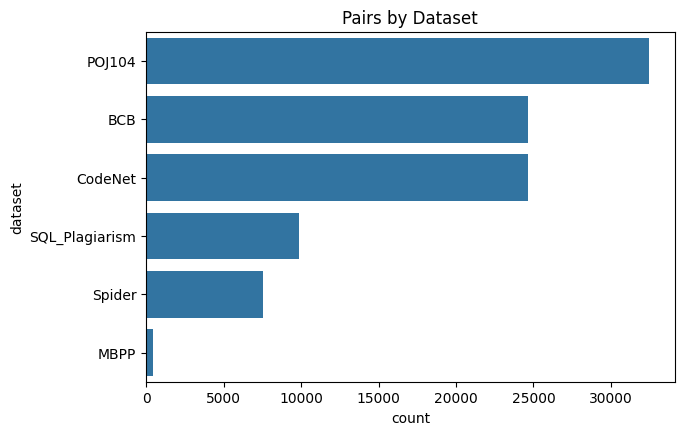

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))

# Plot 1: Distribution by Dataset
plt.subplot(2, 2, 1)
sns.countplot(data=df_cleaned, y='dataset', order=df_cleaned['dataset'].value_counts().index)
plt.title('Pairs by Dataset')

Text(0.5, 1.0, 'Pairs by Language')

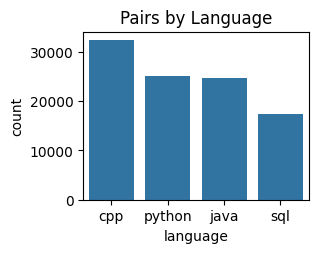

In [ ]:
# Plot 2: Distribution by Language
plt.subplot(2, 2, 2)
sns.countplot(data=df_cleaned, x='language', order=df_cleaned['language'].value_counts().index)
plt.title('Pairs by Language')

Text(0.5, 1.0, 'Code A Word Count Distribution')

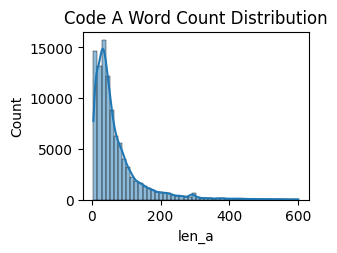

In [ ]:
# Plot 3: Distribution of Code Lengths (Code A)
plt.subplot(2, 2, 3)
sns.histplot(df_cleaned['len_a'], bins=50, kde=True)
plt.title('Code A Word Count Distribution')

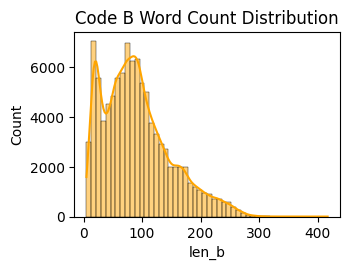

In [ ]:
# Plot 4: Distribution of Code Lengths (Code B)
plt.subplot(2, 2, 4)
sns.histplot(df_cleaned['len_b'], bins=50, kde=True, color='orange')
plt.title('Code B Word Count Distribution')

plt.tight_layout()
plt.show()

In [ ]:
df_final = df_cleaned.drop(columns=['len_a', 'len_b'])

In [ ]:
# df_final.to_csv("Positive SynCode Cleaned Samples.csv")

In [ ]:
for name, df in original_dataframes.items() :
    print(f"Columns in {name}")
    print("*" * 10)

    for col in df.columns.tolist() :
        print (col)
    print ("*" * 30)
    print("\n")

Columns in Original BCB
**********
id
id1
id2
func1
func2
label
******************************


Columns in Original CodeContests
**********
name
description
public_tests
private_tests
generated_tests
source
difficulty
solutions
incorrect_solutions
cf_contest_id
cf_index
cf_points
cf_rating
cf_tags
is_description_translated
untranslated_description
time_limit
memory_limit_bytes
input_file
output_file
******************************


Columns in Original CodeNet
**********
repository_name
func_path_in_repository
func_name
whole_func_string
language
func_code_string
func_documentation_string
func_code_url
******************************


Columns in Original MBPP
**********
source_file
task_id
prompt
code
test_imports
test_list
******************************


Columns in Original Spider SQL
**********
db_id
query
question
query_toks
query_toks_no_value
question_toks
******************************


Columns in Original POJ104
**********
id
code
label
******************************


Columns

In [ ]:
cleaned_positive_data = df_final

In [ ]:
import random
import json

hard_negatives_dfs = []

print("Processing: Extracting Hard Negatives from POJ104...")
poj_df = original_dataframes["Original POJ104"]
poj_list = []

for problem_id, group in poj_df.groupby('label'):
    codes = group['code'].dropna().tolist()
    if len(codes) >= 2:
        num_pairs = min(15, len(codes) // 2)
        for _ in range(num_pairs):
            c1, c2 = random.sample(codes, 2)
            poj_list.append({
                'code_a': c1,
                'code_b': c2,
                'label': 0,
                'language': 'cpp',
                'dataset': 'POJ104_HardNeg'
            })

df_poj_hard = pd.DataFrame(poj_list)
hard_negatives_dfs.append(df_poj_hard)
print(f"Success: Generated {len(df_poj_hard)} samples from POJ104")

print("\nProcessing: Extracting Hard Negatives from CodeContests...")
cc_df = original_dataframes["Original CodeContests"]
cc_list = []

for idx, row in cc_df.iterrows():
    solutions = row['solutions']

    if isinstance(solutions, str):
        try:
            solutions = json.loads(solutions)
        except:
            continue

    if isinstance(solutions, dict) and 'code' in solutions:
        solutions = solutions['code']

    if isinstance(solutions, list) and len(solutions) >= 2:
        num_pairs = min(5, len(solutions) // 2)
        for _ in range(num_pairs):
            c1, c2 = random.sample(solutions, 2)

            code1 = c1['code'] if isinstance(c1, dict) else str(c1)
            code2 = c2['code'] if isinstance(c2, dict) else str(c2)

            cc_list.append({
                'code_a': code1,
                'code_b': code2,
                'label': 0,
                'language': 'python',
                'dataset': 'CodeContests_HardNeg'
            })

if len(cc_list) > 0:
    df_cc_hard = pd.DataFrame(cc_list)
    hard_negatives_dfs.append(df_cc_hard)
    print(f"Success: Generated {len(df_cc_hard)} samples from CodeContests")
else:
    print("Warning: CodeContests schema requires alternative parsing. Handled dynamically but 0 rows found.")

print("\nProcessing: Extracting Hard Negatives from BCB...")
bcb_df = original_dataframes["Original BCB"]

bcb_hard = bcb_df[bcb_df['label'] == 0].head(25000).copy()

df_bcb_hard = pd.DataFrame({
    'code_a': bcb_hard['func1'].values,
    'code_b': bcb_hard['func2'].values,
    'label': 0,
    'language': 'java',
    'dataset': 'BCB_HardNeg'
})
hard_negatives_dfs.append(df_bcb_hard)
print(f"Success: Generated {len(df_bcb_hard)} samples from BCB")

print("\nProcessing: Balancing and shuffling the final dataset...")

all_hard_negatives = pd.concat(hard_negatives_dfs, ignore_index=True)
total_positives_count = len(cleaned_positive_data)
total_hard_negatives_count = len(all_hard_negatives)

needed_easy_negatives = total_positives_count - total_hard_negatives_count

easy_negative_dfs = []
if needed_easy_negatives > 0:
    sampling_fraction = min(1.0, needed_easy_negatives / total_positives_count)

    for lang in cleaned_positive_data['language'].unique():
        lang_df = cleaned_positive_data[cleaned_positive_data['language'] == lang].sample(frac=sampling_fraction, random_state=42).copy()
        lang_df['code_b'] = lang_df['code_b'].sample(frac=1, random_state=42).values
        lang_df['label'] = 0
        easy_negative_dfs.append(lang_df)

    all_easy_negatives = pd.concat(easy_negative_dfs, ignore_index=True)
    if len(all_easy_negatives) > needed_easy_negatives:
        all_easy_negatives = all_easy_negatives.sample(n=needed_easy_negatives, random_state=42).reset_index(drop=True)
else:
    all_easy_negatives = pd.DataFrame(columns=['code_a', 'code_b', 'label', 'language', 'dataset'])

final_dataset = pd.concat([
    cleaned_positive_data,
    all_easy_negatives,
    all_hard_negatives
], ignore_index=True)

final_dataset = final_dataset.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nFinal Dataset Distribution Report:")
print("="*50)
print(f"Total Positives (Label 1):       {len(cleaned_positive_data)}")
print(f"Total Easy Negatives (Label 0):  {len(all_easy_negatives)}")
print(f"Total Hard Negatives (Label 0):  {len(all_hard_negatives)}")
print(f"Grand Total Rows for Training:   {len(final_dataset)}")
print("="*50)

Processing: Extracting Hard Negatives from POJ104...
Success: Generated 975 samples from POJ104

Processing: Extracting Hard Negatives from CodeContests...

Processing: Extracting Hard Negatives from BCB...
Success: Generated 25000 samples from BCB

Processing: Balancing and shuffling the final dataset...

Final Dataset Distribution Report:
Total Positives (Label 1):       99622
Total Easy Negatives (Label 0):  73647
Total Hard Negatives (Label 0):  25975
Grand Total Rows for Training:   199244


In [ ]:
print("Missing values per column:")
print(final_dataset.isnull().sum())
print("-" * 50)

print("Unique dataset breakdown inside final data:")
print(final_dataset['dataset'].value_counts())
print("-" * 50)

preview = final_dataset[['language', 'label', 'dataset']].head(5)
print(preview)

Missing values per column:
code_a      0
code_b      0
label       0
language    0
dataset     0
dtype: int64
--------------------------------------------------
Unique dataset breakdown inside final data:
dataset
POJ104            56495
BCB               42887
CodeNet           42884
BCB_HardNeg       25000
SQL_Plagiarism    17162
Spider            13120
POJ104_HardNeg      975
MBPP                721
Name: count, dtype: int64
--------------------------------------------------
  language  label dataset
0     java      1     BCB
1      cpp      1  POJ104
2      cpp      1  POJ104
3      cpp      1  POJ104
4      cpp      0  POJ104


In [ ]:
print(final_dataset.columns)
print(final_dataset.shape)
final_dataset.to_csv("CoPlag-Contrastive-Dataset.csv")

Index(['code_a', 'code_b', 'label', 'language', 'dataset', 'strat_key'], dtype='object')
(199244, 6)


In [ ]:
# from sklearn.model_selection import train_test_split

# final_dataset['strat_key'] = final_dataset['language'] + "_" + final_dataset['label'].astype(str)

# train_df, temp_df = train_test_split(
#     final_dataset,
#     test_size=0.20,
#     random_state=42,
#     stratify=final_dataset['strat_key']
# )

# val_df, test_df = train_test_split(
#     temp_df,
#     test_size=0.50,
#     random_state=42,
#     stratify=temp_df['strat_key']
# )

# train_df = train_df.drop(columns=['strat_key'])
# val_df = val_df.drop(columns=['strat_key'])
# test_df = test_df.drop(columns=['strat_key'])

# print(f"Dataset Splits Successfully Created:")
# print(f" - Train Set Size:      {len(train_df)} rows")
# print(f" - Validation Set Size: {len(val_df)} rows")
# print(f" - Test Set Size:       {len(test_df)} rows")

Dataset Splits Successfully Created:
 - Train Set Size:      159395 rows
 - Validation Set Size: 19924 rows
 - Test Set Size:       19925 rows
